In [33]:
from keras.utils import to_categorical
from keras_preprocessing.image import load_img, img_to_array
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
import os
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

import zipfile
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from sklearn.metrics import accuracy_score

In [9]:
zip_path = '/content/archive.zip'  # Path to your ZIP file
extract_path = '/content'  # Destination folder

# Create extraction directory if not exists
os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files extracted to: {extract_path}")

Files extracted to: /content


In [10]:
TRAIN_DIR = '/content/train'
TEST_DIR = '/content/test'

In [11]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir, label)):
            image_paths.append(os.path.join(dir, label, imagename))
            labels.append(label)
        print(label, "completed")
    return image_paths, labels

In [12]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

print(train)

neutral completed
surprise completed
sad completed
happy completed
angry completed
disgust completed
fear completed
                                              image    label
0      /content/train/neutral/Training_76808814.jpg  neutral
1      /content/train/neutral/Training_27350607.jpg  neutral
2      /content/train/neutral/Training_16111179.jpg  neutral
3      /content/train/neutral/Training_61029987.jpg  neutral
4      /content/train/neutral/Training_39695497.jpg  neutral
...                                             ...      ...
28704     /content/train/fear/Training_53893619.jpg     fear
28705     /content/train/fear/Training_62711791.jpg     fear
28706     /content/train/fear/Training_84171314.jpg     fear
28707     /content/train/fear/Training_94830038.jpg     fear
28708     /content/train/fear/Training_64355740.jpg     fear

[28709 rows x 2 columns]


In [13]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

print(test)

neutral completed
surprise completed
sad completed
happy completed
angry completed
disgust completed
fear completed
                                               image    label
0      /content/test/neutral/PrivateTest_5309902.jpg  neutral
1     /content/test/neutral/PrivateTest_73234678.jpg  neutral
2     /content/test/neutral/PrivateTest_94444867.jpg  neutral
3      /content/test/neutral/PublicTest_52510808.jpg  neutral
4      /content/test/neutral/PublicTest_40964978.jpg  neutral
...                                              ...      ...
7173     /content/test/fear/PrivateTest_14661354.jpg     fear
7174     /content/test/fear/PrivateTest_79352177.jpg     fear
7175      /content/test/fear/PublicTest_67013660.jpg     fear
7176     /content/test/fear/PrivateTest_18859828.jpg     fear
7177     /content/test/fear/PrivateTest_71935283.jpg     fear

[7178 rows x 2 columns]


In [ ]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode="grayscale")
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features),48, 48, 1)
    return features

In [ ]:
train_features = extract_features(train['image'])

  0%|          | 0/28709 [00:00<?, ?it/s]

In [ ]:
test_features = extract_features(test['image'])

  0%|          | 0/7178 [00:00<?, ?it/s]

In [ ]:
X_train = train_features/255.0
X_test = test_features/255.0

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [ ]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [ ]:
y_train = to_categorical(y_train, num_classes = 7)
y_test = to_categorical(y_test, num_classes = 7)

In [ ]:
model = Sequential()

# Input Layer
model.add(Input(shape=(48, 48, 1)))

#Convolutional Layers
model.add(Conv2D(128, kernel_size = (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size = (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size = (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size = (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.4))

model.add(Flatten())

#Fully Connected Layers
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.3))

#Output Layer
model.add(Dense(7, activation = 'softmax'))

In [ ]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
model.fit(x = X_train, y = y_train, batch_size = 128, epochs = 100, validation_data = (X_test, y_test))

Epoch 1/100
225/225 [==============================] - 243s 1s/step - loss: 1.8240 - accuracy: 0.2459 - val_loss: 1.8144 - val_accuracy: 0.2471
Epoch 2/100
225/225 [==============================] - 241s 1s/step - loss: 1.8079 - accuracy: 0.2520 - val_loss: 1.8023 - val_accuracy: 0.2508
Epoch 3/100
225/225 [==============================] - 239s 1s/step - loss: 1.7630 - accuracy: 0.2680 - val_loss: 1.6911 - val_accuracy: 0.3065
Epoch 4/100
225/225 [==============================] - 237s 1s/step - loss: 1.6726 - accuracy: 0.3256 - val_loss: 1.5484 - val_accuracy: 0.3870
Epoch 5/100
225/225 [==============================] - 238s 1s/step - loss: 1.5697 - accuracy: 0.3848 - val_loss: 1.4604 - val_accuracy: 0.4365
Epoch 6/100
225/225 [==============================] - 238s 1s/step - loss: 1.4894 - accuracy: 0.4208 - val_loss: 1.4291 - val_accuracy: 0.4391
Epoch 7/100
225/225 [==============================] - 238s 1s/step - loss: 1.4451 - accuracy: 0.4389 - val_loss: 1.3362 - val_accuracy:

In [ ]:
model_json = model.to_json()
with open("emotiondetector.json",'w') as json_file:
    json_file.write(model_json)
model.save("emotiondetector.h5")

In [21]:
from tensorflow.keras.models import Sequential, model_from_json
import json

# Load JSON model
with open("/content/emotiondetector.json", "r") as json_file:
    model_json = json_file.read()

model = model_from_json(model_json, custom_objects={"Sequential": Sequential})
model.load_weights("/content/emotiondetector.h5")

In [22]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']

In [23]:
def ef(image):
    img = load_img(image,grayscale =  True )
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    return feature/255.0

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
model prediction is  sad


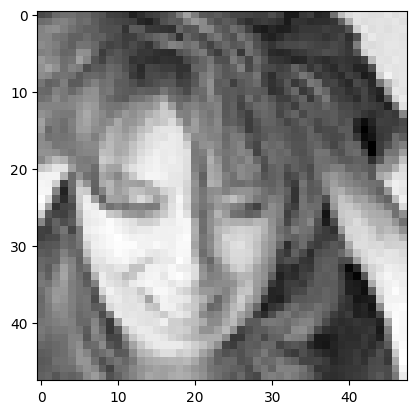

In [29]:
image = '/content/train/sad/Training_10022789.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

In [34]:
# Define emotion classes
EMOTION_CLASSES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

def evaluate_emotion_model(model, test_folder, img_size=(48, 48)):
    class_accuracies = {}
    all_predictions = []
    all_actuals = []

    for class_idx, class_name in enumerate(EMOTION_CLASSES):
        class_path = os.path.join(test_folder, class_name)
        if not os.path.isdir(class_path):
            continue  # Skip if not a directory

        correct = 0
        total = 0
        predictions = []
        actuals = []

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                # Load and preprocess image
                img = load_img(img_path, target_size=img_size, color_mode="grayscale")  # Assuming grayscale
                img_array = img_to_array(img) / 255.0  # Normalize
                img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
                img_array = np.expand_dims(img_array, axis=-1)  # Ensure correct shape (48, 48, 1)

                # Get model prediction
                pred = model.predict(img_array, verbose=0)
                predicted_class = np.argmax(pred)  # Get class index

                # Store results
                actuals.append(class_idx)
                predictions.append(predicted_class)
                all_actuals.append(class_idx)
                all_predictions.append(predicted_class)

                if predicted_class == class_idx:
                    correct += 1
                total += 1
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

        # Compute accuracy for this class
        class_accuracy = correct / total if total > 0 else 0
        class_accuracies[class_name] = class_accuracy
        print(f"Accuracy for {class_name}: {class_accuracy:.2%} ({correct}/{total})")

    # Compute overall accuracy
    overall_accuracy = accuracy_score(all_actuals, all_predictions)
    print(f"\nOverall Accuracy: {overall_accuracy:.2%}")

    return class_accuracies


In [35]:
# Load the trained model
model = tf.keras.models.load_model("/content/emotiondetector.h5")

# Define test folder path
test_folder_path = "/content/test"

# Evaluate the model
classwise_accuracies = evaluate_emotion_model(model, test_folder_path)

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Accuracy for angry: 50.84% (487/958)
Accuracy for disgust: 47.75% (53/111)
Accuracy for fear: 36.13% (370/1024)
Accuracy for happy: 86.08% (1527/1774)
Accuracy for neutral: 66.99% (826/1233)
Accuracy for sad: 48.04% (599/1247)
Accuracy for surprise: 80.14% (666/831)

Overall Accuracy: 63.08%
